# Class 3: Adaptive Capacity

## Objective
**Score adaptive capacity as High (3), Medium (2), or Low (1)** based on when the building was constructed relative to flood regulation adoption dates.

We will assess how well buildings are prepared to withstand or adapt to flooding by examining their construction dates relative to important flood regulation milestones in Asheville/Buncombe County.

---

## What is Adaptive Capacity?

**Adaptive capacity** is a measure of how well an asset (in this case, a building) can withstand or adapt to a hazard (flooding). Think of it like:

- A person in good health is more *adaptive* to illness than someone with chronic disease
- A newer car with modern safety features is more *adaptive* to accidents than a 1970s car
- A building designed with flood-resistant features is more *adaptive* to flooding than an older building

### The Key Question for Flooding:
**When was this building built?** If it was built after flood regulations were implemented, the building was designed with those regulations in mind (elevated foundations, flood-resistant materials, etc.). If it was built before, it probably was not.

---

## Why Does "Year Built" Matter?

Building codes evolve over time as we learn more about hazards. Flood-resistant building practices were not widespread until the **National Flood Insurance Program (NFIP)** started requiring them in the 1970s-1980s.

### Key Dates for Asheville/Buncombe County:

| Period | Regulation Status | Adaptive Capacity |
|--------|------------------|-------------------|
| **Before 1980** | Built before NFIP participation — no flood-resistant design required | **LOW (1)** |
| **1981–2010** | Built after initial NFIP rules — BFE* of 1 foot above base flood elevation | **MEDIUM (2)** |
| **After 2010** | Built after stricter current rules — BFE of 2 feet above base flood elevation | **HIGH (3)** |

*BFE = Base Flood Elevation (the expected water level during a 100-year flood)

### Special Case: Not Exposed Parcels
If a parcel is **not exposed to flood risk** (from Class 1), it automatically gets **HIGH (3)** adaptive capacity because there is no flood risk to adapt to.

---

## Learning Goals for This Class

By the end of this class, you will be able to:

1. **Understand** why building age relates to flood resilience
2. **Calculate** adaptive capacity scores based on regulatory dates
3. **Handle** missing data responsibly in GIS analysis
4. **Visualize** adaptive capacity on a map
5. **Summarize** results with statistical tables

Let's get started!


## Step 0: Setup

In this section, we mount Google Drive and install all required libraries. This is standard for any Google Colab notebook that needs to access files from your Drive.


In [ ]:
# Mount Google Drive so we can access our data files
from google.colab import drive
import os
drive.mount('/content/drive')

# Define the base directory where our data lives in Google Drive
BASE_DIR = '/content/drive/MyDrive/MSER_510_VULNERABILTY'
DATA_DIR = os.path.join(BASE_DIR, 'data')

# GeoPackage file paths for chained loading/saving
INPUT_GPKG = os.path.join(DATA_DIR, 'class_2_impact.gpkg')  # Load from Class 2
OUTPUT_GPKG = os.path.join(DATA_DIR, 'class_3_adaptive_capacity.gpkg')  # Save to Class 3
CLASS0_GPKG = os.path.join(DATA_DIR, 'vulnerability_risk_data.gpkg')  # Fallback for base layers

# Check that the input file exists
if os.path.exists(INPUT_GPKG):
    print(f"✓ Input data file found: {INPUT_GPKG}")
else:
    print(f"✗ Input data file NOT found at: {INPUT_GPKG}")
    print("Please ensure Class 2 was completed first")

### Optional: Run Locally Instead of Google Colab

If you prefer to run this notebook on your own machine (e.g., using Jupyter or VS Code) instead of Google Colab, comment out the Google Drive cell above and uncomment the cell below. Update the `BASE_DIR` path to point to a folder on your local filesystem.

In [ ]:
# LOCAL RUN: Uncomment the lines below to run locally instead of Google Colab
# Update the path to match your local folder

# import os

# BASE_DIR = './'
# DATA_DIR = os.path.join(BASE_DIR, 'data')
# OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')

# os.makedirs(DATA_DIR, exist_ok=True)
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# INPUT_GPKG = os.path.join(DATA_DIR, 'class_2_impact.gpkg')
# OUTPUT_GPKG = os.path.join(DATA_DIR, 'class_3_adaptive_capacity.gpkg')
# CLASS0_GPKG = os.path.join(DATA_DIR, 'vulnerability_risk_data.gpkg')

In [85]:
# Install libraries we need for GIS analysis
!pip install geopandas fiona shapely pyproj requests folium seaborn contextily --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [86]:
# Import all the libraries we'll use
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium import plugins
import os
import warnings
warnings.filterwarnings('ignore')

# Set up for nice-looking plots
plt.style.use('seaborn-v0_8-darkgrid')

## Step 1: Load Data

We'll load the parcels layer from the GeoPackage. This layer should have:
- **exposure** field from Class 1 (1 = exposed to flood zone, 0 = not exposed)
- **potential_impact** field from Class 2 (how severe the impact would be if flooded)
- **structyear** field (year the building was constructed) from NC OneMap
- **geometry** (the parcel boundaries as polygons)

Let's load it and check its contents.


In [87]:
# List all layers in the GeoPackage to see what we have
import fiona
layers = fiona.listlayers(INPUT_GPKG)
print(f"Layers in {os.path.basename(INPUT_GPKG)}:")
for layer in layers:
    print(f"  - {layer}")

Layers in class_2_impact.gpkg:
  - parcels
  - flood_zones_100yr
  - study_area
  - flood_zones
  - buildings


In [88]:
# Load the parcels layer from the INPUT GeoPackage (from Class 2)
try:
    parcels = gpd.read_file(INPUT_GPKG, layer='parcels')
    print(f"✓ Successfully loaded 'parcels' layer from Class 2")
    print(f"  Total parcels: {len(parcels):,}")
    print(f"  Columns: {list(parcels.columns)}")
except Exception as e:
    print(f"✗ Error loading parcels: {e}")
    print(f"Attempting fallback from CLASS0_GPKG: {CLASS0_GPKG}")
    try:
        parcels = gpd.read_file(CLASS0_GPKG, layer='parcels')
        print(f"✓ Successfully loaded from fallback")
    except Exception as e2:
        print(f"✗ Fallback also failed: {e2}")
        parcels = None

✓ Successfully loaded 'parcels' layer from Class 2
  Total parcels: 16,078
  Columns: ['objectid', 'parno', 'altparno', 'ownname', 'improvval', 'landval', 'parval', 'mailadd', 'munit', 'mcity', 'mstate', 'mzip', 'siteadd', 'sunit', 'scity', 'gisacres', 'struct', 'multistruc', 'saledate', 'saledatetx', 'legdecfull', 'parusecode', 'parusedesc', 'parusecd2', 'parusedsc2', 'parvaltype', 'owntype', 'recareano', 'recareatx', 'revisedate', 'sourceref', 'sourcedate', 'sourcedatx', 'subdivisio', 'nparno', 'cntyname', 'cntyfips', 'stfips', 'stcntyfips', 'gnisid', 'sourceagnt', 'transfdate', 'maddpref', 'maddrno', 'maddstname', 'maddstr', 'maddstsuf', 'maddsttyp', 'ownfrst', 'ownlast', 'revdatetx', 'reviseyear', 'saddno', 'saddpref', 'saddstname', 'saddstr', 'saddstsuf', 'saddsttyp', 'sstate', 'stname', 'subowntype', 'subsurfown', 'szip', 'structno', 'structyear', 'ownname2', 'presentval', 'mapref', 'st_area(shape)', 'st_perimeter(shape)', 'FLD_ZONE', 'ZONE_SUBTY', 'flood_category', 'exposure', '

In [89]:
# Check that the required fields exist
required_fields = ['exposure', 'potential_impact', 'sourcedate']
missing_fields = [f for f in required_fields if f not in parcels.columns]

if missing_fields:
    print(f"⚠ WARNING: Missing fields: {missing_fields}")
    print("Make sure you completed Classes 1 and 2 before this class!")
else:
    print(f"✓ All required fields present")

# Display the first few rows to understand the data structure
print("First 5 rows of data:")
print(parcels[['exposure', 'potential_impact', 'sourcedate']].head())

✓ All required fields present
First 5 rows of data:
   exposure  potential_impact sourcedate
0         0                 0       None
1         1                 1       None
2         1                 2       None
3         0                 0       None
4         0                 0       None


## Step 2: Explore the structyear Field

**What is sourcedatx?**

sourcedatx is a field from NC OneMap that we can use as a proxy for the year a building was constructed. It's based on property tax records and public data. Some parcels may have missing values (NULL) if the data was not recorded or the building is very new. and it should be best data to proxy the year a structure is built.

Let's explore this field to understand what we're working with:
- What's the range of years?
- Are there missing values?
- What does the distribution look like?


In [90]:
# Convert saledatetx from string to datetime, then extract year
parcels['source_dt'] = pd.to_datetime(parcels['sourcedatx'], errors='coerce')
parcels['structyear'] = parcels['source_dt'].dt.year

# Get basic statistics about sale year
print("saledatetx Summary Statistics:")
print("=" * 50)
print(f"  Minimum year:     {parcels['structyear'].min():.0f}")
print(f"  Maximum year:     {parcels['structyear'].max():.0f}")
print(f"  Mean year:        {parcels['structyear'].mean():.1f}")
print(f"  Median year:      {parcels['structyear'].median():.0f}")
print()

# Count missing or zero values
null_count = parcels['structyear'].isna().sum()
zero_count = (parcels['structyear'] == 0).sum()
valid_count = len(parcels) - null_count - zero_count

print(f"  Valid years:      {valid_count:,} parcels ({100*valid_count/len(parcels):.1f}%)")
print(f"  Null/Missing:     {null_count:,} parcels ({100*null_count/len(parcels):.1f}%)")
print(f"  Zero values:      {zero_count:,} parcels ({100*zero_count/len(parcels):.1f}%)")
print(f"  Total parcels:    {len(parcels):,}")

saledatetx Summary Statistics:
  Minimum year:     1854
  Maximum year:     2026
  Mean year:        2011.6
  Median year:      2017

  Valid years:      16,078 parcels (100.0%)
  Null/Missing:     0 parcels (0.0%)
  Zero values:      0 parcels (0.0%)
  Total parcels:    16,078


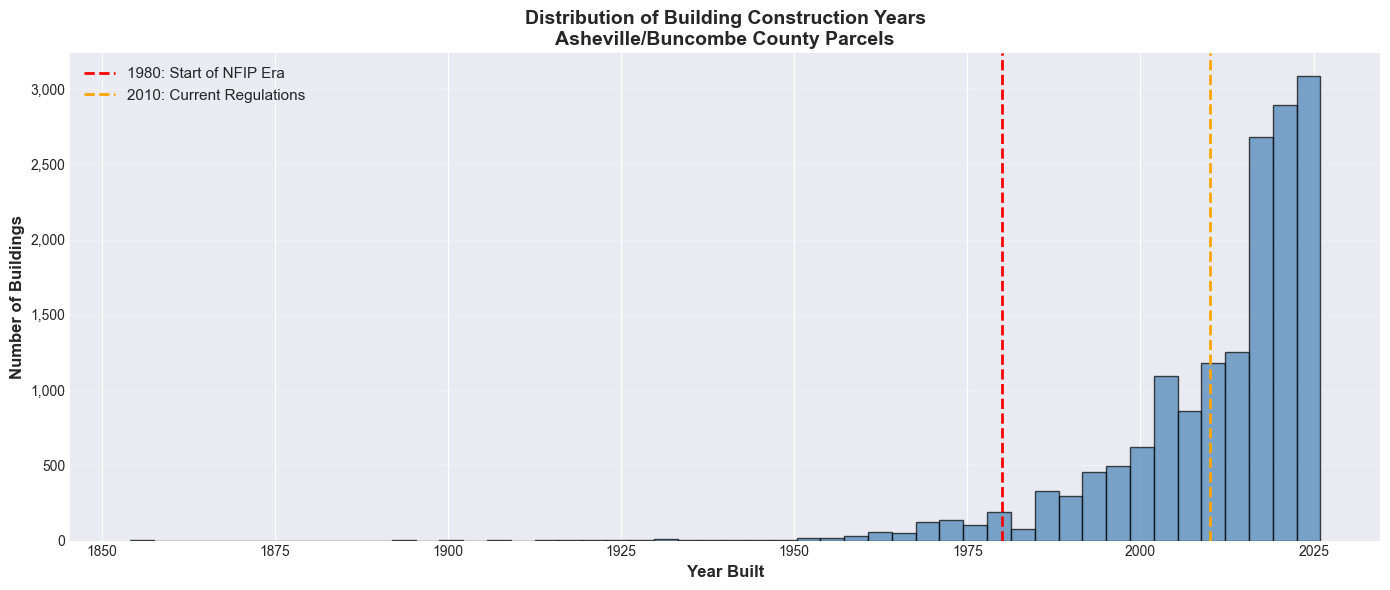

This histogram shows when buildings were built.
The vertical lines mark the key flood regulation dates.


In [91]:
# Create a histogram showing the distribution of building years
fig, ax = plt.subplots(figsize=(14, 6))

# Filter out zero and null values for the histogram
valid_years = parcels[parcels['structyear'] > 0]['structyear'].dropna()

# Create the histogram
ax.hist(valid_years, bins=50, color='steelblue', edgecolor='black', alpha=0.7)

# Add vertical lines for the key regulation dates
ax.axvline(1980, color='red', linestyle='--', linewidth=2, label='1980: Start of NFIP Era')
ax.axvline(2010, color='orange', linestyle='--', linewidth=2, label='2010: Current Regulations')

# Labels and formatting
ax.set_xlabel('Year Built', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Buildings', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Building Construction Years\nAsheville/Buncombe County Parcels',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Format y-axis as thousands with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print(f"This histogram shows when buildings were built.")
print(f"The vertical lines mark the key flood regulation dates.")

### What Does the Histogram Tell Us?

Look at the histogram above:

1. **Before 1980 (red line):** How many buildings were built before flood regulations?
2. **1980-2010 (between red and orange lines):** How many were built under early regulations?
3. **After 2010 (orange line):** How many were built under current stricter rules?

Buildings built after each line should be progressively more flood-resistant. This is the basis for our adaptive capacity scoring!


## Step 3: Handle Missing Data

**The Problem:** Some parcels don't have a year built recorded in structyear. We can't calculate adaptive capacity without knowing when the building was constructed.

**Our Strategy:**
- For missing or zero structyear values, we'll assign **MEDIUM (2)** adaptive capacity
- This is a reasonable default: we assume a building of unknown age has moderate flood-resistant features
- We'll document this decision clearly so anyone using our results understands what we did

**Why Medium and not Low?**
- If we assumed Low, we'd be too pessimistic about buildings we know nothing about
- If we assumed High, we'd be too optimistic
- Medium reflects uncertainty: unknown buildings are a mixed bag

This is a common practice in risk assessment called "conservative uncertainty handling."


In [92]:
# Check for missing structyear values before we calculate adaptive capacity
print("Missing structyear Assessment:")
print("=" * 50)

# Count the nulls and zeros
null_mask = parcels['structyear'].isna()
zero_mask = parcels['structyear'] == 0
missing_mask = null_mask | zero_mask

print(f"Parcels with NULL structyear:     {null_mask.sum():,}")
print(f"Parcels with structyear = 0:      {zero_mask.sum():,}")
print(f"Total missing/invalid:             {missing_mask.sum():,} ({100*missing_mask.sum()/len(parcels):.2f}%)")
print()
print("Decision: We will assign MEDIUM (2) adaptive capacity to all missing values.")
print("This reflects that buildings of unknown age are not automatically weak or strong.")

Missing structyear Assessment:
Parcels with NULL structyear:     0
Parcels with structyear = 0:      0
Total missing/invalid:             0 (0.00%)

Decision: We will assign MEDIUM (2) adaptive capacity to all missing values.
This reflects that buildings of unknown age are not automatically weak or strong.


## Step 4: Calculate Adaptive Capacity

Now we'll create the **adaptive_capacity** field using the scoring rules:

| Condition | Adaptive Capacity Score |
|-----------|-------------------------|
| Parcel NOT exposed to flooding (exposure = 0) | **HIGH (3)** |
| Missing or zero structyear | **MEDIUM (2)** |
| Built before 1980 | **LOW (1)** |
| Built 1981–2010 | **MEDIUM (2)** |
| Built after 2010 | **HIGH (3)** |

We'll use a custom function to apply these rules to each parcel.


In [93]:
# Define the function to calculate adaptive capacity
def calculate_adaptive_capacity(row):
    """
    Calculate adaptive capacity score based on exposure and year built.

    Returns:
      3 = HIGH: Not exposed, or built after 2010
      2 = MEDIUM: Exposed + missing data, or built 1981-2010
      1 = LOW: Exposed + built before 1980
    """

    # If parcel is not exposed to flood risk, high adaptive capacity (no risk to adapt to!)
    if row['exposure'] == 0:
        return 3

    # If year built is missing or zero, assign medium as default
    if pd.isna(row['structyear']) or row['structyear'] == 0:
        return 2

    # Apply the year-built thresholds for exposed parcels
    year = row['structyear']

    if year < 1980:
        # Built before flood regulations took effect
        return 1  # LOW adaptive capacity
    elif year <= 2010:
        # Built under initial regulations
        return 2  # MEDIUM adaptive capacity
    else:
        # Built under current stricter regulations
        return 3  # HIGH adaptive capacity

# Apply this function to every row in the parcels dataframe
parcels['adaptive_capacity'] = parcels.apply(calculate_adaptive_capacity, axis=1)

print("✓ Adaptive capacity calculated for all parcels")
print(f"  Data type: {parcels['adaptive_capacity'].dtype}")
print(f"  Unique values: {sorted(parcels['adaptive_capacity'].unique())}  (1=Low, 2=Medium, 3=High)")

✓ Adaptive capacity calculated for all parcels
  Data type: int64
  Unique values: [np.int64(1), np.int64(2), np.int64(3)]  (1=Low, 2=Medium, 3=High)


In [94]:
# Verify the calculation by looking at some examples
print("Sample calculations (first 10 parcels):")
print("=" * 100)

sample = parcels[['exposure', 'structyear', 'adaptive_capacity']].head(10).copy()
sample.columns = ['Exposure', 'Year Built', 'AC Score']

print(sample.to_string())
print()

# Print the logic for a few rows
print("Logic check:")
for idx in range(min(3, len(parcels))):
    row = parcels.iloc[idx]
    exp = row['exposure']
    year = row['structyear']
    ac = row['adaptive_capacity']

    if exp == 0:
        reason = "Not exposed"
    elif pd.isna(year) or year == 0:
        reason = "Missing year built (defaulted to Medium)"
    elif year < 1980:
        reason = "Built before 1980 (before flood regulations)"
    elif year <= 2010:
        reason = "Built 1981-2010 (under early regulations)"
    else:
        reason = "Built after 2010 (under current regulations)"

    print(f"  Parcel {idx}: exposure={exp}, year={int(year) if not pd.isna(year) else 'NULL'} → AC={ac} ({reason})")

Sample calculations (first 10 parcels):
   Exposure  Year Built  AC Score
0         0        2020         3
1         1        2001         2
2         1        2022         3
3         0        2024         3
4         0        2022         3
5         0        2018         3
6         0        2013         3
7         0        1964         3
8         0        2024         3
9         0        2010         3

Logic check:
  Parcel 0: exposure=0, year=2020 → AC=3 (Not exposed)
  Parcel 1: exposure=1, year=2001 → AC=2 (Built 1981-2010 (under early regulations))
  Parcel 2: exposure=1, year=2022 → AC=3 (Built after 2010 (under current regulations))


## Step 5: Summary Statistics

Let's see what our adaptive capacity results look like. We'll calculate:
- How many parcels are at each adaptive capacity level?
- What's the total property value for each level?
- How does adaptive capacity relate to asset type?


In [95]:
# Count of parcels at each adaptive capacity level
print("Distribution of Adaptive Capacity:")
print("=" * 60)

ac_counts = parcels['adaptive_capacity'].value_counts().sort_index(ascending=False)
ac_labels = {3: 'HIGH', 2: 'MEDIUM', 1: 'LOW'}

for ac_level in [3, 2, 1]:
    count = ac_counts.get(ac_level, 0)
    pct = 100 * count / len(parcels)
    label = ac_labels[ac_level]
    bar = '█' * int(pct / 2)  # ASCII bar chart
    print(f"  {label:8} ({ac_level}): {count:7,} parcels  {pct:5.1f}%  {bar}")

print(f"  {'TOTAL':8}      {len(parcels):7,} parcels  100.0%")

Distribution of Adaptive Capacity:
  HIGH     (3):  15,237 parcels   94.8%  ███████████████████████████████████████████████
  MEDIUM   (2):     733 parcels    4.6%  ██
  LOW      (1):     108 parcels    0.7%  
  TOTAL          16,078 parcels  100.0%


In [96]:
# If your data has parcel_value field, summarize by adaptive capacity
# (If not, this will be skipped with a message)

if 'parval' in parcels.columns:
    print("\nTotal Parcel Value by Adaptive Capacity:")
    print("=" * 60)

    value_by_ac = parcels.groupby('adaptive_capacity')['parval'].agg([
        ('Count', 'count'),
        ('Total Value', 'sum'),
        ('Mean Value', 'mean'),
        ('Median Value', 'median')
    ]).reindex([3, 2, 1])

    value_by_ac.index = value_by_ac.index.map(lambda x: ['LOW', 'MEDIUM', 'HIGH'][3-x])

    # Format currency nicely
    for col in ['Total Value', 'Mean Value', 'Median Value']:
        value_by_ac[col] = value_by_ac[col].apply(lambda x: f'${x:,.0f}')

    print(value_by_ac.to_string())
else:
    print("Note: 'parval' field not found in data. Skipping value summary.")


Total Parcel Value by Adaptive Capacity:
                   Count     Total Value  Mean Value Median Value
adaptive_capacity                                                
LOW                15237  $5,094,428,074    $334,346     $236,000
MEDIUM               733    $609,405,000    $831,385     $183,700
HIGH                 108    $391,831,200  $3,628,067     $166,200


In [97]:
# Calculate structure_value as parval - landval
parcels['structure_value'] = parcels['parval'] - parcels['landval']

# Summarize structure value by adaptive capacity
print("\nTotal Structure Value by Adaptive Capacity:")
print("=" * 60)

struct_by_ac = parcels.groupby('adaptive_capacity')['structure_value'].agg([
    ('Count', 'count'),
    ('Total Value', 'sum'),
    ('Mean Value', 'mean'),
    ('Median Value', 'median')
]).reindex([3, 2, 1])

struct_by_ac.index = struct_by_ac.index.map(lambda x: ['LOW', 'MEDIUM', 'HIGH'][3-x])

# Format currency nicely
for col in ['Total Value', 'Mean Value', 'Median Value']:
    struct_by_ac[col] = struct_by_ac[col].apply(lambda x: f'${x:,.0f}')

print(struct_by_ac.to_string())


Total Structure Value by Adaptive Capacity:
                   Count     Total Value  Mean Value Median Value
adaptive_capacity                                                
LOW                15237  $3,805,006,274    $249,721     $182,200
MEDIUM               733    $430,779,200    $587,693      $48,100
HIGH                 108    $258,661,800  $2,395,017      $20,100


In [98]:
# Cross-tabulation: Adaptive Capacity vs Exposure Status
print("\nAdaptive Capacity vs Exposure to Flooding:")
print("=" * 60)

crosstab = pd.crosstab(
    parcels['adaptive_capacity'].map({1: 'LOW', 2: 'MEDIUM', 3: 'HIGH'}),
    parcels['exposure'].map({0: 'Not Exposed', 1: 'Exposed'}),
    margins=True
)

print(crosstab.to_string())

print("\nKey Insight:")
print("  - HIGH parcels should include: all non-exposed + exposed post-2010 buildings")
print("  - MEDIUM parcels should include: exposed 1981-2010 buildings + missing data")
print("  - LOW parcels should include: exposed pre-1980 buildings")


Adaptive Capacity vs Exposure to Flooding:
exposure           Exposed  Not Exposed    All
adaptive_capacity                             
HIGH                  1388        13849  15237
LOW                    108            0    108
MEDIUM                 733            0    733
All                   2229        13849  16078

Key Insight:
  - HIGH parcels should include: all non-exposed + exposed post-2010 buildings
  - MEDIUM parcels should include: exposed 1981-2010 buildings + missing data
  - LOW parcels should include: exposed pre-1980 buildings


## Step 6: Map Adaptive Capacity

Now let's visualize adaptive capacity on a map. We'll use:
- **RED** for LOW (1) adaptive capacity — older buildings with limited flood resilience
- **YELLOW** for MEDIUM (2) adaptive capacity — moderate flood resilience
- **GREEN** for HIGH (3) adaptive capacity — newer, more resilient buildings

The map will help us see where vulnerable buildings are concentrated geographically.


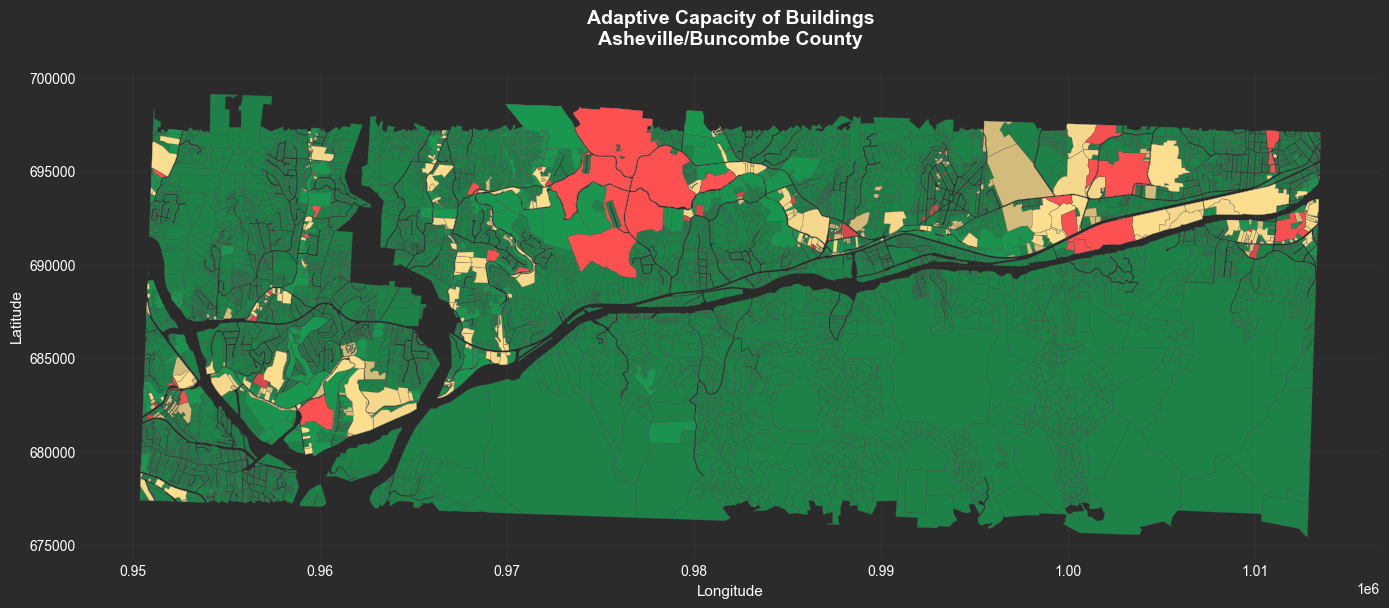

Map shows adaptive capacity by color:
  RED (#ff5252) = LOW adaptive capacity (1) - pre-1980 buildings at risk
  CREAM/YELLOW (#fee090) = MEDIUM adaptive capacity (2) - moderate resilience
  DARK GREEN (#1a9850) = HIGH adaptive capacity (3) - newer, more resilient buildings or not exposed
  GRAY (#757575) = NONE/Unknown (0) - no data


In [99]:
# Create a simple matplotlib map of adaptive capacity
fig, ax = plt.subplots(figsize=(14, 10), facecolor='#2b2b2b')
ax.set_facecolor('#2b2b2b')

# Define colors for adaptive capacity levels using official symbology
# Score 0 (None/Unknown) = #757575, 1 (Low) = #ff5252, 2 (Medium) = #fee090, 3 (High) = #1a9850
colors = {
    0: '#757575',   # Gray for None/Unknown
    1: '#ff5252',   # Red for LOW
    2: '#fee090',   # Cream/Light yellow for MEDIUM
    3: '#1a9850'    # Dark green for HIGH
}

ac_labels = {0: 'NONE', 1: 'LOW', 2: 'MEDIUM', 3: 'HIGH'}

# Plot each adaptive capacity level
for ac_level in [3, 2, 1, 0]:
    subset = parcels[parcels['adaptive_capacity'] == ac_level]
    if len(subset) > 0:
        subset.plot(ax=ax, color=colors[ac_level], edgecolor='#555555', linewidth=0.2,
                    alpha=0.8, label=f'{ac_labels[ac_level]} ({len(subset):,})')

ax.set_title('Adaptive Capacity of Buildings\nAsheville/Buncombe County',
             fontsize=14, fontweight='bold', pad=20, color='white')
ax.set_xlabel('Longitude', fontsize=11, color='white')
ax.set_ylabel('Latitude', fontsize=11, color='white')
ax.legend(loc='upper right', fontsize=11, framealpha=0.95, facecolor='#3a3a3a', 
          edgecolor='#555555', labelcolor='white')
ax.grid(True, alpha=0.2, color='#555555')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('#555555')

plt.tight_layout()
plt.show()

print("Map shows adaptive capacity by color:")
print("  RED (#ff5252) = LOW adaptive capacity (1) - pre-1980 buildings at risk")
print("  CREAM/YELLOW (#fee090) = MEDIUM adaptive capacity (2) - moderate resilience")
print("  DARK GREEN (#1a9850) = HIGH adaptive capacity (3) - newer, more resilient buildings or not exposed")
print("  GRAY (#757575) = NONE/Unknown (0) - no data")

In [100]:
from IPython.display import HTML
import folium

# Define colors for each adaptive capacity level using official symbology
# Score 0 (None/Unknown) = #757575, 1 (Low) = #ff5252, 2 (Medium) = #fee090, 3 (High) = #1a9850
consequence_colors = {
    0: '#757575',     # Gray - None/Unknown
    1: '#ff5252',     # Red - Low
    2: '#fee090',     # Cream/Light yellow - Medium
    3: '#1a9850'      # Dark green - High
}

# Calculate the center of the map
center_lat = parcels.geometry.centroid.y.mean()
center_lon = parcels.geometry.centroid.x.mean()

# Create the base map with dark basemap
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles='https://{s}.basemaps.cartocdn.com/dark_all/{z}/{x}/{y}{r}.png',
    attr='CartoDB',
    width='100%',
    height='450px'
)

# Define color mapping
def get_color(ac_value):
    if ac_value == 1:
        return '#ff5252'  # RED
    elif ac_value == 2:
        return '#fee090'  # CREAM/YELLOW
    elif ac_value == 3:
        return '#1a9850'  # DARK GREEN
    else:
        return '#757575'  # GRAY

# Add each parcel as a polygon to the map
for idx, row in parcels.iterrows():
    try:
        # Get coordinates from the geometry
        coords = [[lat, lon] for lon, lat in zip(
            row.geometry.exterior.coords.xy[0],
            row.geometry.exterior.coords.xy[1]
        )]

        # Create popup text
        ac_label = ['NONE', 'LOW', 'MEDIUM', 'HIGH'][int(row['adaptive_capacity'])]
        year_built = int(row['structyear']) if not pd.isna(row['structyear']) else 'Unknown'
        exposed_label = 'Yes' if row['exposure'] == 1 else 'No'
        popup_text = f"<b>Adaptive Capacity: {ac_label}</b><br>Year Built: {year_built}<br>Exposed: {exposed_label}"

        folium.Polygon(
            locations=coords,
            color=get_color(row['adaptive_capacity']),
            weight=1,
            opacity=0.6,
            fill=True,
            fillOpacity=0.5,
            popup=folium.Popup(popup_text, max_width=300)
        ).add_to(m)
    except:
        # Skip any problematic geometries
        pass

# Add a title
title_html = '''
             <div style="position: fixed;
                     top: 10px; left: 50px; width: 350px; height: 100px;
                     background-color: #2b2b2b; border:2px solid #888; z-index:9999;
                     font-size:14px; padding: 10px; border-radius: 5px; color: white;">
             <b>Adaptive Capacity Map</b><br>
             RED (#ff5252) = Low | CREAM (#fee090) = Medium | DARK GREEN (#1a9850) = High<br>
             GRAY (#757575) = None/Unknown<br>
             Click parcels for details
             </div>
             '''
m.get_root().html.add_child(folium.Element(title_html))

# Display the map with HTML wrapper
map_html = m._repr_html_()
display(HTML(f'<div style="height:450px;overflow:hidden;">{map_html}</div>'))

## Export Adaptive Capacity Map to PNG

We'll create a high-resolution PNG map showing the adaptive capacity assessment with all layers properly styled and ordered.

✓ Buildings loaded: 22222 features
✓ Flood zones loaded: 233 features
  Categories: {'100-year': 109, '500-year': 108, 'Floodway': 16}


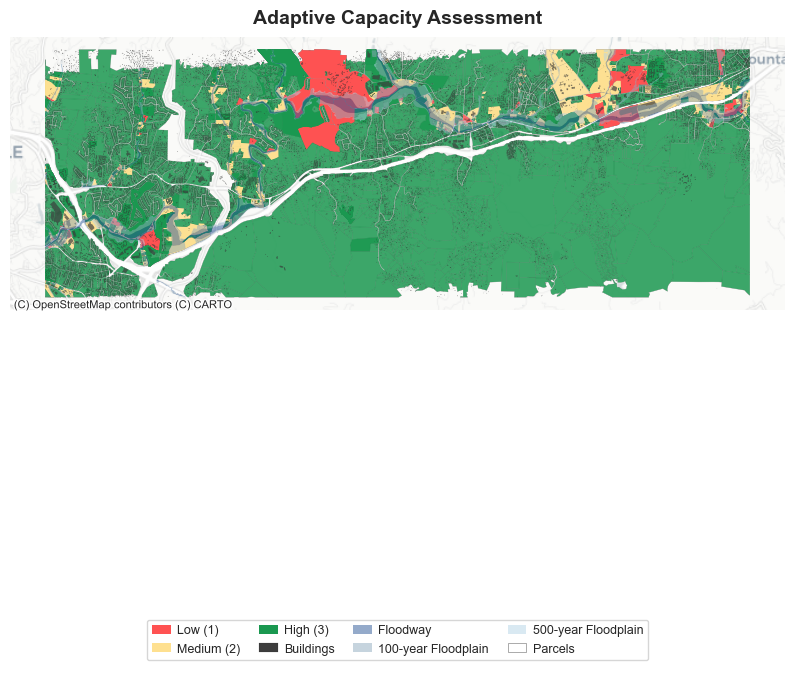

✓ Map exported to: ./outputs/adaptive_capacity_map.png


In [101]:
import contextily as ctx
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

# Reproject to Web Mercator for basemap tiles
parcels_wm = parcels.to_crs(epsg=3857)

# Create figure with map panel + legend panel below
fig = plt.figure(figsize=(10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios=[10, 1.2], hspace=0.02)
ax = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

# Layer 1 (bottom): All parcels - no fill, thin grey borders
parcels_wm.plot(ax=ax, facecolor='none', edgecolor='#888888', linewidth=0.3)

# Layer 2: Adaptive capacity layer - score 0 NOT plotted
# Color mapping for adaptive capacity
ac_colors = {1: '#ff5252', 2: '#fee090', 3: '#1a9850'}
for score in [1, 2, 3]:
    subset = parcels_wm[parcels_wm['adaptive_capacity'] == score]
    if len(subset) > 0:
        subset.plot(ax=ax, facecolor=ac_colors[score], edgecolor='none', alpha=0.85)

# Layer 3: Buildings
try:
    buildings_layer = gpd.read_file(CLASS0_GPKG, layer='buildings')
    buildings_wm = buildings_layer.to_crs(epsg=3857)
    buildings_wm.plot(ax=ax, facecolor='#3D3D3D', edgecolor='#2a2a2a', linewidth=0.1, alpha=0.7)
    print(f"✓ Buildings loaded: {len(buildings_layer)} features")
except Exception as e:
    print(f"⚠ Could not load buildings: {e}")

# Layer 4: Flood zones with transparency (all three categories)
try:
    flood_zones_full = gpd.read_file(CLASS0_GPKG, layer='flood_zones')
    flood_wm = flood_zones_full.to_crs(epsg=3857)
    flood_colors = {'Floodway': '#2B5797', '100-year': '#8FABBE', '500-year': '#B4D4E7'}
    for flood_type in ['500-year', '100-year', 'Floodway']:
        flood_subset = flood_wm[flood_wm['flood_category'] == flood_type]
        if len(flood_subset) > 0:
            flood_subset.plot(ax=ax, facecolor=flood_colors.get(flood_type, '#B4D4E7'),
                            edgecolor='none', alpha=0.5)
    print(f"✓ Flood zones loaded: {len(flood_zones_full)} features")
    print(f"  Categories: {flood_zones_full['flood_category'].value_counts().to_dict()}")
except Exception as e:
    print(f"⚠ Could not load flood zones: {e}")

# Add CartoDB Positron (light) basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto')

# Style the map panel
ax.set_axis_off()
ax.set_title('Adaptive Capacity Assessment', fontsize=14, fontweight='bold', pad=10)

# Build legend in bottom panel
ax_legend.set_axis_off()
legend_elements = [
    Patch(facecolor='#ff5252', edgecolor='none', label='Low (1)'),
    Patch(facecolor='#fee090', edgecolor='none', label='Medium (2)'),
    Patch(facecolor='#1a9850', edgecolor='none', label='High (3)'),
    Patch(facecolor='#3D3D3D', edgecolor='#2a2a2a', linewidth=0.1, label='Buildings'),
    Patch(facecolor='#2B5797', edgecolor='none', alpha=0.5, label='Floodway'),
    Patch(facecolor='#8FABBE', edgecolor='none', alpha=0.5, label='100-year Floodplain'),
    Patch(facecolor='#B4D4E7', edgecolor='none', alpha=0.5, label='500-year Floodplain'),
    Patch(facecolor='none', edgecolor='#888888', linewidth=0.5, label='Parcels'),
]
ax_legend.legend(handles=legend_elements, loc='center', ncol=4, fontsize=9,
                frameon=True, facecolor='white', edgecolor='#cccccc',
                handlelength=1.5, handletextpad=0.5, columnspacing=1.5)

# Export
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
png_path = os.path.join(OUTPUT_DIR, 'adaptive_capacity_map.png')
plt.savefig(png_path, dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print(f"✓ Map exported to: {png_path}")

## Step 7: Save Results

Now we save the updated parcels layer (with the new adaptive_capacity field) back to the GeoPackage. This allows us to use these results in Class 4 (Risk Score) and future analyses.


In [102]:
try:
    import fiona
    import sqlite3
    
    # Save parcels layer first (creates new GeoPackage)
    parcels.to_file(OUTPUT_GPKG, layer='parcels', driver='GPKG', mode='w')
    print(f"✓ Saved parcels layer with adaptive_capacity ({len(parcels)} features)")
    
    # Copy forward all other layers from the input GeoPackage
    if os.path.exists(INPUT_GPKG):
        input_layers = fiona.listlayers(INPUT_GPKG)
        for layer_name in input_layers:
            if layer_name == 'parcels':
                continue  # Already saved updated version
            try:
                layer_data = gpd.read_file(INPUT_GPKG, layer=layer_name)
                layer_data.to_file(OUTPUT_GPKG, layer=layer_name, driver='GPKG', mode='a')
                print(f"✓ Copied layer: {layer_name} ({len(layer_data)} features)")
            except Exception as e:
                print(f"  Note: Could not copy layer '{layer_name}' as spatial: {e}")
        
        # Also copy any non-spatial tables (like 'summary') via sqlite3
        try:
            conn_in = sqlite3.connect(INPUT_GPKG)
            conn_out = sqlite3.connect(OUTPUT_GPKG)
            cursor = conn_in.cursor()
            # Get all tables that aren't in fiona's layer list and aren't system tables
            cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
            all_tables = [row[0] for row in cursor.fetchall()]
            system_tables = ['gpkg_contents', 'gpkg_geometry_columns', 'gpkg_spatial_ref_sys',
                            'gpkg_ogr_contents', 'gpkg_tile_matrix', 'gpkg_tile_matrix_set',
                            'sqlite_sequence', 'gpkg_extensions', 'gpkg_metadata',
                            'gpkg_metadata_reference']
            for table in all_tables:
                if table in system_tables or table in input_layers or table.startswith('rtree_') or table.startswith('trigger_'):
                    continue
                try:
                    df = pd.read_sql(f'SELECT * FROM "{table}"', conn_in)
                    if len(df) > 0:
                        df.to_sql(table, conn_out, if_exists='replace', index=False)
                        print(f"✓ Copied non-spatial table: {table} ({len(df)} rows)")
                except Exception:
                    pass
            conn_in.close()
            conn_out.close()
        except Exception:
            pass
    
    # Also ensure base layers from Class 0 are included (flood_zones, buildings, study_area)
    # These may not be in INPUT_GPKG if earlier classes didn't carry them forward
    if os.path.exists(CLASS0_GPKG):
        try:
            import fiona as _fiona
            # Get layers already written to output
            output_layers = _fiona.listlayers(OUTPUT_GPKG)
            # Get layers available in Class 0
            class0_layers = _fiona.listlayers(CLASS0_GPKG)
            # Copy any missing layers
            for layer_name in class0_layers:
                if layer_name not in output_layers:
                    try:
                        layer_data = gpd.read_file(CLASS0_GPKG, layer=layer_name)
                        layer_data.to_file(OUTPUT_GPKG, layer=layer_name, driver='GPKG', mode='a')
                        print(f"✓ Added base layer from Class 0: {layer_name} ({len(layer_data)} features)")
                    except Exception as e:
                        print(f"  Note: Could not copy base layer '{layer_name}': {e}")
        except Exception:
            pass
    
    print(f"\n✓ All data saved to: {OUTPUT_GPKG}")
except Exception as e:
    print(f"✗ Error saving to GeoPackage: {e}")
    print("\nAlternative: Save to a new GeoPackage file")
    alt_path = os.path.join(DATA_DIR, 'class_3_adaptive_capacity_backup.gpkg')
    parcels.to_file(alt_path, layer='parcels', driver='GPKG')
    print(f"✓ Saved to: {alt_path}")

✓ Saved parcels layer with adaptive_capacity (16078 features)
✓ Copied layer: flood_zones_100yr (250 features)
✓ Copied layer: study_area (1 features)
✓ Copied layer: flood_zones (233 features)
✓ Copied layer: buildings (22222 features)

✓ All data saved to: ./data/class_3_adaptive_capacity.gpkg


In [103]:
# Verify the save by reading it back
try:
    verify = gpd.read_file(OUTPUT_GPKG, layer='parcels')
    if 'adaptive_capacity' in verify.columns:
        print("✓ Verification successful!")
        print(f"  'adaptive_capacity' field is present in saved file")
        print(f"  Value counts in saved file:")
        print(verify['adaptive_capacity'].value_counts().sort_index(ascending=False))
    else:
        print("⚠ Warning: 'adaptive_capacity' field not found in saved file")
except Exception as e:
    print(f"✗ Error verifying save: {e}")

✓ Verification successful!
  'adaptive_capacity' field is present in saved file
  Value counts in saved file:
adaptive_capacity
3    15237
2      733
1      108
Name: count, dtype: int64


## Step 8: Interpretation & Next Steps

### What We've Accomplished

We've scored **adaptive capacity** — a measure of how well buildings can withstand flooding — based on:

1. **Building construction date** relative to flood regulation dates
2. **Exposure status** from Class 1
3. **Data quality** (handling missing structyear values responsibly)

### Key Takeaways

- **Older buildings (pre-1980)** in flood zones have LOW adaptive capacity. They were built before anyone thought about flood-resistant design.
- **Medium-age buildings (1981-2010)** have MEDIUM adaptive capacity. They follow basic flood regulations.
- **Newer buildings (post-2010)** have HIGH adaptive capacity. They meet current stricter standards.
- **Not-exposed buildings** always have HIGH adaptive capacity — even if old — because they're not at risk.

### Next Steps

In **Class 4: Risk Score**, we'll combine:
- **Hazard** (flood probability from Class 1)
- **Exposure** (buildings in flood zones)
- **Vulnerability** (potential impact from Class 2)
- **Adaptive Capacity** (resilience we calculated here)

...to create a final **RISK SCORE** that tells us which properties are most at risk.

### Questions to Discuss

1. Why do you think adaptive capacity based on building age makes sense?
2. Are there any other factors that might affect a building's ability to withstand flooding (besides age)?
3. Why did we assign MEDIUM capacity to buildings with missing construction dates?

---


## Appendix A: QGIS Equivalent Expression

If you wanted to calculate adaptive capacity in **QGIS** instead of Python, you could use the **Field Calculator** with this expression:

```qgis
CASE
  WHEN "exposure" = 0 THEN 3
  WHEN "structyear" IS NULL OR "structyear" = 0 THEN 2
  WHEN "structyear" < 1980 THEN 1
  WHEN "structyear" >= 1981 AND "structyear" <= 2010 THEN 2
  WHEN "structyear" > 2010 THEN 3
  ELSE 2
END
```

### Steps in QGIS:

1. Load the parcels layer
2. Open **Layer → Fields → New Field** (or double-click to edit existing layer)
3. Create field named **adaptive_capacity** (type: Integer)
4. Right-click the field → **Edit Field**
5. Switch to **Field Calculator** mode
6. Paste the expression above
7. Click **OK** to apply to all rows

The logic is identical to our Python function!


## Appendix B: ArcGIS Pro Equivalent

If you wanted to calculate adaptive capacity in **ArcGIS Pro**, you could use **Calculate Field** with a Python expression.

### ArcGIS Pro Field Calculator Expression:

```python
def calc_adaptive_capacity(exposure, structyear):
    """Calculate adaptive capacity score"""
    if exposure == 0:
        return 3  # Not exposed
    if structyear is None or structyear == 0:
        return 2  # Missing data
    if structyear < 1980:
        return 1  # Low - pre-1980
    elif structyear <= 2010:
        return 2  # Medium - 1981-2010
    else:
        return 3  # High - post-2010

calc_adaptive_capacity(!exposure!, !structyear!)
```

### Steps in ArcGIS Pro:

1. Load the parcels feature class
2. Right-click the **adaptive_capacity** field → **Calculate**
3. Set **Parser** to **Python 3**
4. Define the function above in the expression area
5. Call it with: `calc_adaptive_capacity(!exposure!, !structyear!)`
6. Click **OK** to apply

This approach is best practice in ArcGIS because it's readable and reusable!


## Conclusion

Congratulations! You've successfully scored adaptive capacity for all buildings in the study area.

**You now understand:**
- Why building age matters for flood resilience
- How to handle missing data responsibly
- How to calculate scores based on regulatory thresholds
- How to visualize and summarize your results

This adaptive capacity score is now ready for use in the final **Risk Assessment** coming in Class 4!

---

**GIS Vulnerability & Risk Assessment Course**
Class 3: Adaptive Capacity
Asheville/Buncombe County Case Study
